# Task 1.1 — Sentiment Analysis with a Feedforward ANN

We classify Amazon product reviews as **positive (1)** or **negative (0)** using a
TF-IDF bag-of-words representation fed into a simple feedforward neural network.

**Pipeline overview**
```
Raw text  →  Preprocessing  →  TF-IDF vectors  →  ANN  →  {0, 1}
```

## Setup & Imports

In [1]:
import nltk
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from data_loading_code import preprocess_pandas
from utils import device_check, fit, evaluate


nltk.download('punkt',        quiet=True)
nltk.download('punkt_tab',    quiet=True)
nltk.download('stopwords',    quiet=True)

# Suppress NumPy 2.4 VisibleDeprecationWarning triggered inside torchvision
warnings.filterwarnings("ignore", category=np.exceptions.VisibleDeprecationWarning)

device = device_check()

PyTorch: 2.11.0+cpu | Python: 3.13.7 | OS: Windows 11
CUDA available: False
Using cpu


## Notebook parameters

In [3]:
LOG_WANDB   = True  # Set False to disable wandb logging
NUM_WORKERS = 8
PIN_MEMORY  = True
SEED = 1

# Make results reproducible
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Load & Preprocess Data

In [6]:
raw = pd.read_csv('../data/amazon_cells_labelled.txt', delimiter='\t', header=None,
                  names=['Sentence', 'Class'])
print(f'Loaded {len(raw)} reviews')
print(raw['Class'].value_counts().rename({0: 'negative', 1: 'positive'}))
raw.head()

Loaded 1000 reviews
Class
negative    500
positive    500
Name: count, dtype: int64


,Sentence,Class
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [7]:
data = preprocess_pandas(raw)
data.head()

,Sentence,Class
0,way plug us unless go converter,0
1,good case excellent value,1
2,great jawbone,1
3,tied charger conversations lasting minutesmajo...,0
4,mic great,1


## Train / Validation / Test Split

We carve out a held-out **test set** first (10 %), then further split the remainder
into **train** (81 %) and **validation** (9 %) sets.

In [8]:
sentences = data['Sentence'].values.astype('U')
labels    = data['Class'].values.astype('int32')

# First, split off the test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    sentences, labels, test_size=0.10, random_state=SEED, shuffle=True, stratify=labels
)

# Then split train/val from the remaining data
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.10, random_state=SEED, shuffle=True, stratify=y_trainval
)

print(f'Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}')

Train: 810  |  Val: 90  |  Test: 100


## TF-IDF Vectorization

The vectorizer is **fit only on the training set** to avoid data leakage, then used
to transform all three splits.

In [9]:
vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),   # unigrams + bigrams
    max_features=50_000,
    max_df=0.5,
    use_idf=True,
    norm='l2',
)

X_train_tfidf = torch.from_numpy(np.array(vectorizer.fit_transform(X_train).todense())).float()
X_val_tfidf   = torch.from_numpy(np.array(vectorizer.transform(X_val).todense())).float()
X_test_tfidf  = torch.from_numpy(np.array(vectorizer.transform(X_test).todense())).float()

y_train_t = torch.from_numpy(y_train).long()
y_val_t   = torch.from_numpy(y_val).long()
y_test_t  = torch.from_numpy(y_test).long()

INPUT_DIM = X_train_tfidf.shape[1]
print(f'Vocabulary size (TF-IDF features): {INPUT_DIM}')

Vocabulary size (TF-IDF features): 4671


## DataLoaders

In [11]:
BATCH_SIZE = 32

train_loader = DataLoader(TensorDataset(X_train_tfidf, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_tfidf,   y_val_t),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_test_tfidf,  y_test_t),  batch_size=BATCH_SIZE, shuffle=False)

## Model Definition

A three-layer feedforward network with **BatchNorm** and **Dropout** for regularisation.

```
Input (vocab_size)  →  FC(256) → BN → ReLU → Dropout
                    →  FC(64)  → BN → ReLU → Dropout
                    →  FC(2)   →  logits
```

In [12]:
class SentimentANN(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list[int], dropout: float = 0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 2))  # 2 output classes
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


model = SentimentANN(input_dim=INPUT_DIM, hidden_dims=[256, 64], dropout=0.3).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

SentimentANN(
  (net): Sequential(
    (0): Linear(in_features=4671, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=2, bias=True)
  )
)

Trainable parameters: 1,213,250


## Training

In [13]:
NUM_EPOCHS = 20
LR         = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

wandb_kwargs = {
    'project': 'lab1-sentiment',
    'name':    'ann-tfidf-baseline',
    'config':  {
        'hidden_dims': [256, 64],
        'dropout':     0.3,
        'lr':          LR,
        'batch_size':  BATCH_SIZE,
        'epochs':      NUM_EPOCHS,
        'optimizer':   'Adam',
    },
}

# Set log=True if you have wandb set up, otherwise leave as False
history = fit(
    model, optimizer, criterion,
    train_loader, val_loader,
    num_epochs=NUM_EPOCHS,
    wandb_kwargs=wandb_kwargs,
    log=False,
)

Epoch  1/20 | train loss 0.5651, train acc 70.12% | val loss 0.6779, val acc 51.11%
Epoch  2/20 | train loss 0.2091, train acc 96.17% | val loss 0.5983, val acc 64.44%
Epoch  3/20 | train loss 0.0888, train acc 98.52% | val loss 0.4764, val acc 76.67%
Epoch  4/20 | train loss 0.0431, train acc 99.88% | val loss 0.5249, val acc 76.67%
Epoch  5/20 | train loss 0.0350, train acc 99.88% | val loss 0.5416, val acc 77.78%
Epoch  6/20 | train loss 0.0264, train acc 99.75% | val loss 0.5761, val acc 78.89%
Epoch  7/20 | train loss 0.0195, train acc 99.88% | val loss 0.6403, val acc 80.00%
Epoch  8/20 | train loss 0.0147, train acc 99.88% | val loss 0.6282, val acc 77.78%
Epoch  9/20 | train loss 0.0139, train acc 99.75% | val loss 0.6413, val acc 75.56%
Epoch 10/20 | train loss 0.0118, train acc 99.63% | val loss 0.6784, val acc 77.78%
Epoch 11/20 | train loss 0.0163, train acc 99.75% | val loss 0.6571, val acc 81.11%
Epoch 12/20 | train loss 0.0115, train acc 99.63% | val loss 0.6620, val acc

## Learning Curves

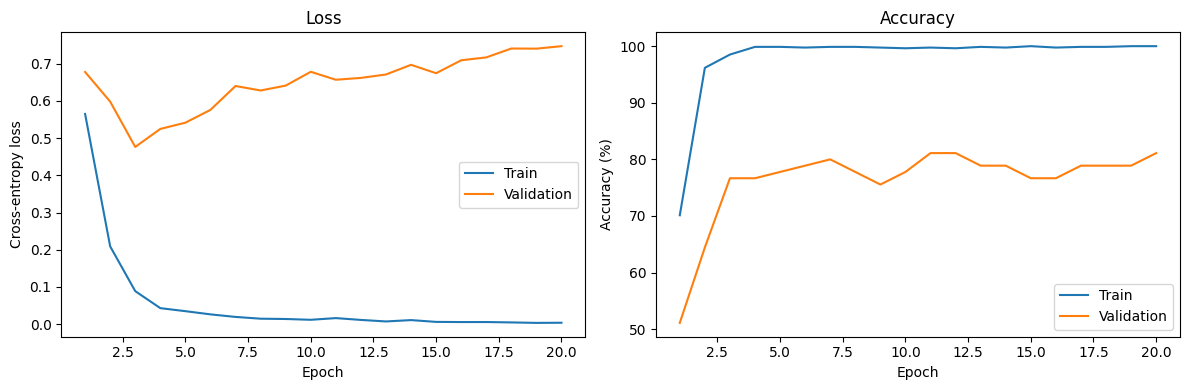

In [14]:
epochs = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history['train_loss'], label='Train')
ax1.plot(epochs, history['val_loss'],   label='Validation')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-entropy loss')
ax1.legend()

ax2.plot(epochs, history['train_acc'], label='Train')
ax2.plot(epochs, history['val_acc'],   label='Validation')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.tight_layout()
plt.show()

## Evaluation on the Test Set

In [15]:
evaluate(model, test_loader, criterion, label='ANN TF-IDF baseline')

[ANN TF-IDF baseline] Test loss: 0.4402 | Test acc: 79.00%


(0.44017558634281156, 79.0)

In [16]:
# Collect all predictions for detailed metrics
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        preds  = model(inputs).argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.81      0.76      0.78        50
    Positive       0.77      0.82      0.80        50

    accuracy                           0.79       100
   macro avg       0.79      0.79      0.79       100
weighted avg       0.79      0.79      0.79       100



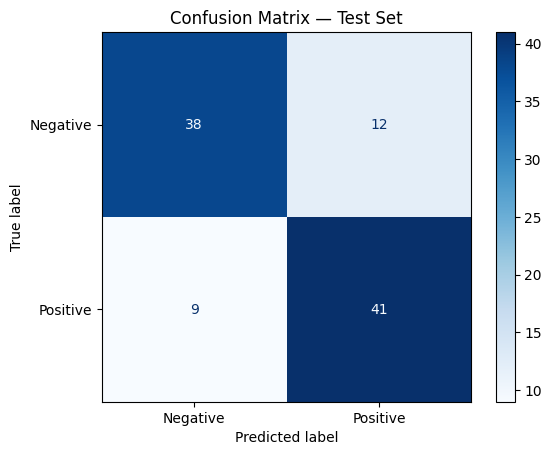

In [17]:
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=['Negative', 'Positive']).plot(cmap='Blues')
plt.title('Confusion Matrix — Test Set')
plt.show()

## Quick Inference Demo

In [18]:
def predict(texts: list[str]) -> list[str]:
    """Return 'Positive' / 'Negative' predictions for a list of raw review strings."""
    vec   = torch.from_numpy(np.array(vectorizer.transform(texts).todense())).float().to(device)
    model.eval()
    with torch.no_grad():
        preds = model(vec).argmax(dim=1).cpu().numpy()
    return ['Positive' if p == 1 else 'Negative' for p in preds]


examples = [
    "Absolutely love this phone, battery lasts all day!",
    "Terrible product, broke after two days. Complete waste of money.",
    "It's okay, nothing special but gets the job done.",
]

for text, label in zip(examples, predict(examples)):
    print(f'[{label}]  {text}')

[Negative]  Absolutely love this phone, battery lasts all day!
[Negative]  Terrible product, broke after two days. Complete waste of money.
[Positive]  It's okay, nothing special but gets the job done.
